# **Point Net - Classification**

In [1]:
import os
import re
from glob import glob
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
from torchmetrics.classification import MulticlassMatthewsCorrCoef
import open3d as o3

from open3d.web_visualizer import draw # for non Colab
import os, os.path as osp

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.


In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

In [3]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import warnings
from models.point_net.point_net import PointNetClassHead
from shapely.geometry import Polygon
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm

# from analyze_pointnet_backbone import analyze_pointnet_backbone
from models.point_net.analyze_pointnet_backbone import analyze_pointnet_backbone2
plots = True
  

### cls_model_35

1000
[cls_model_35] Model loaded from: models/point_net/trained_models/cls_focal_clr/cls_model_35.pth
[cls_model_35] Collected features: X=(1000, 1024), labels=(1000,)
[cls_model_35] Saved extracted features to:
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_default\cls_model_35_default_features.csv
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_default\cls_model_35_default_features.parquet
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.016s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.000117
[t-SNE] KL divergence after 250 iterations with early exaggeration: 51.405407
[t-SNE] KL divergence after 1000 iterations: 0.404191
[PointNet] t-SNE computed: X2=(1000, 2)
[p

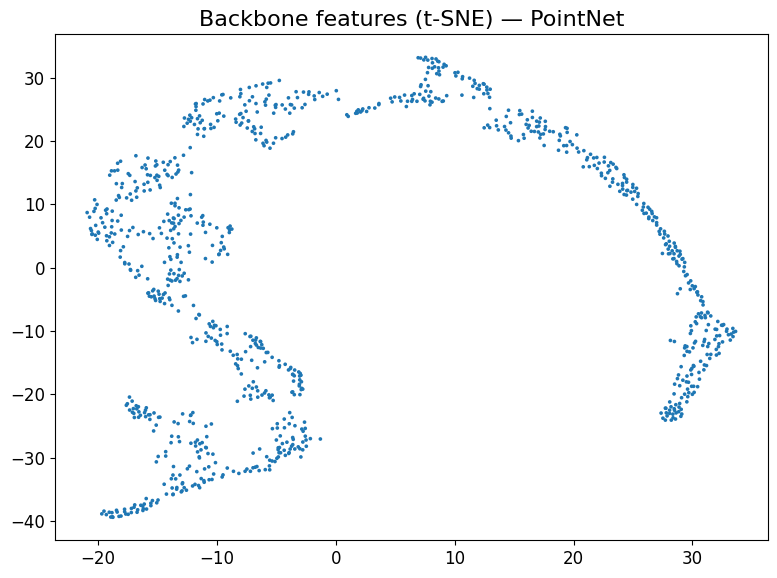

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_default\PointNet_tsne_area.png


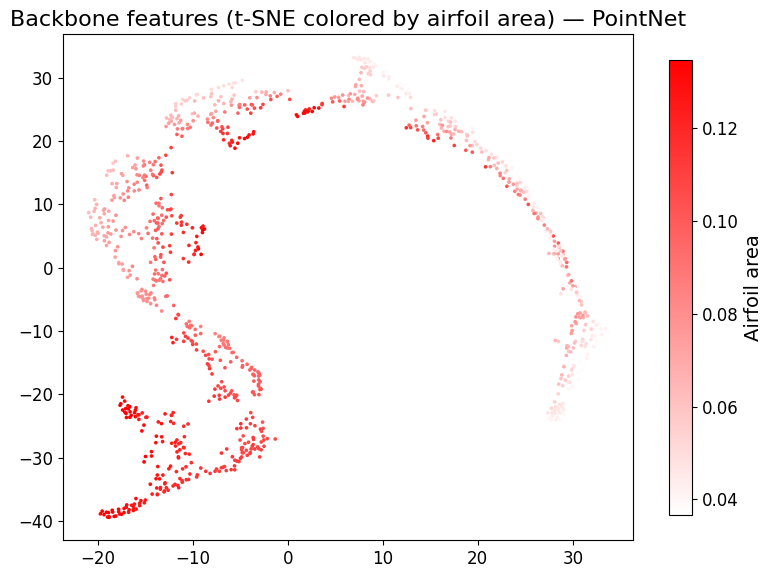

[PointNet] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_default\PointNet_tsne_camber.png


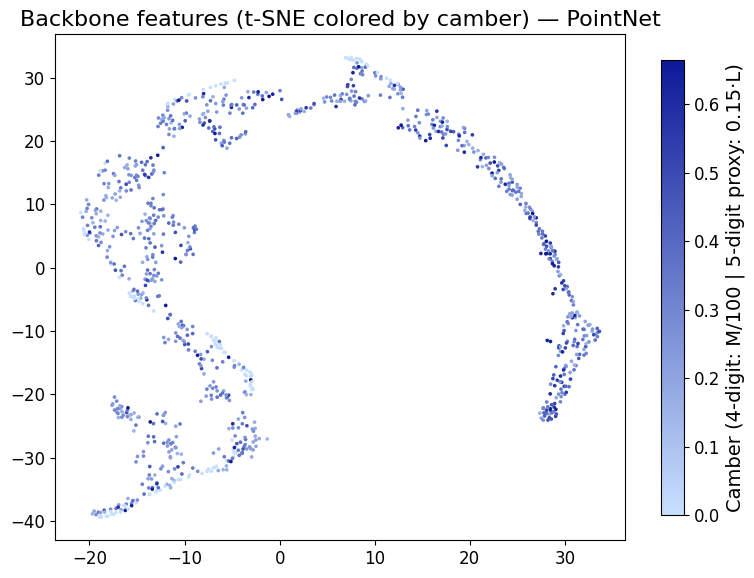

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_default\PointNet_tsne_thickness.png


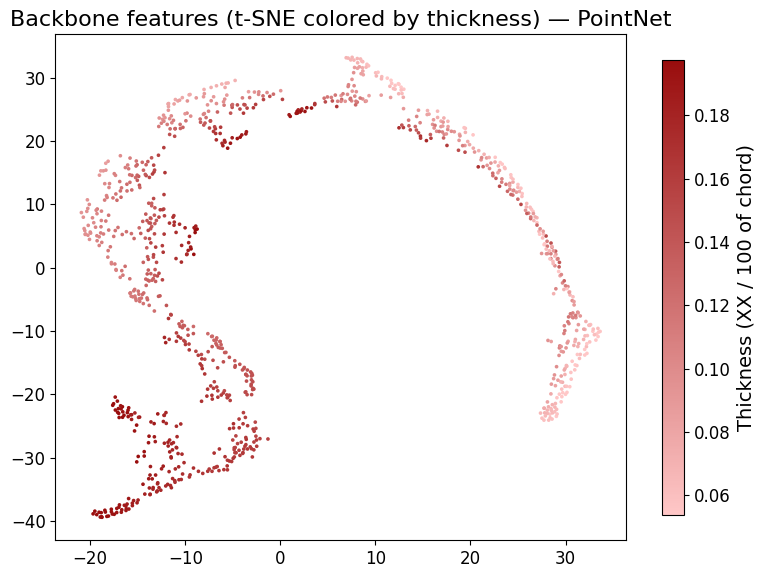

[PointNet] Plotting t-SNE colored by area, camber, and thickness.
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_default\PointNet_tsne_area_camber_thickness.png


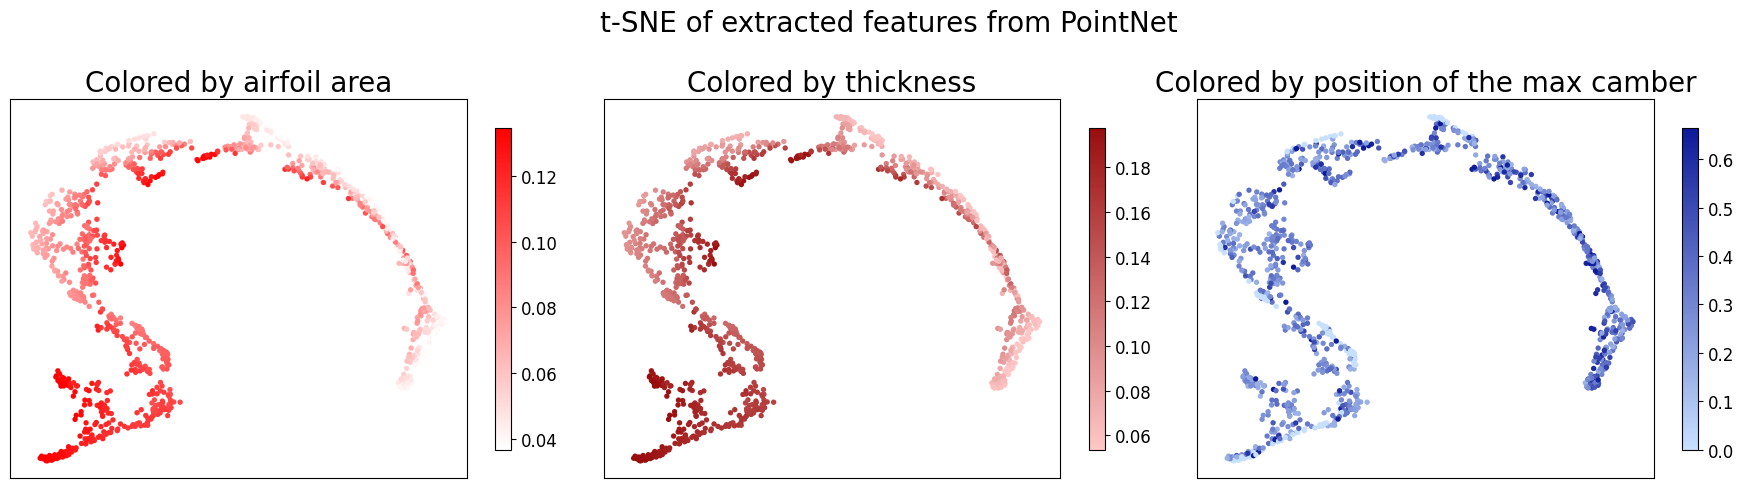

In [4]:
out35 = analyze_pointnet_backbone2('models/point_net/trained_models/cls_focal_clr/cls_model_35.pth', DEVICE, class_choice = ["default"], plots = plots, data_folder = "shapenet_like_out3")

1000
[cls_model_35] Model loaded from: models/point_net/trained_models/cls_focal_clr/cls_model_35.pth
[cls_model_35] Collected features: X=(1000, 1024), labels=(1000,)
[cls_model_35] Saved extracted features to:
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_centered\cls_model_35_centered_features.csv
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_centered\cls_model_35_centered_features.parquet
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.021s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.000070
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.590820
[t-SNE] KL divergence after 1000 iterations: 0.614696
[cls_model_35] t-SNE computed: X2=(100

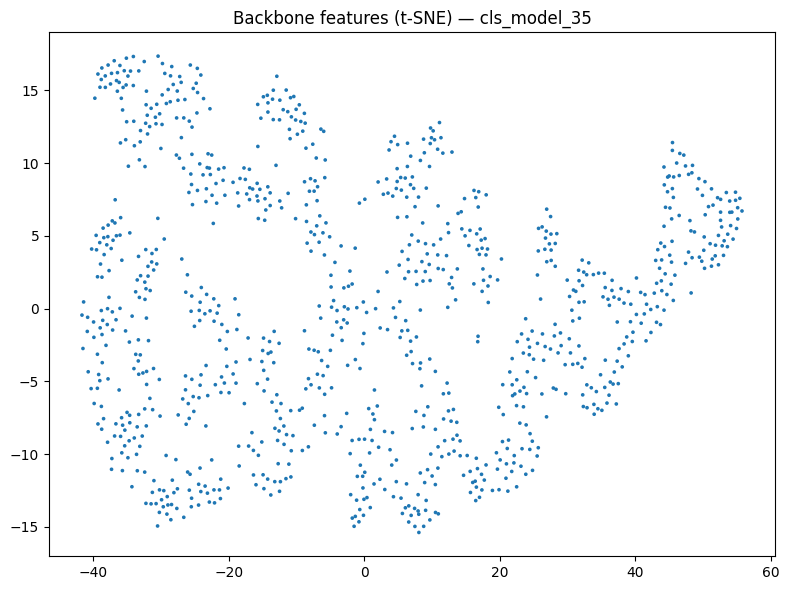

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_centered\cls_model_35_tsne_area.png


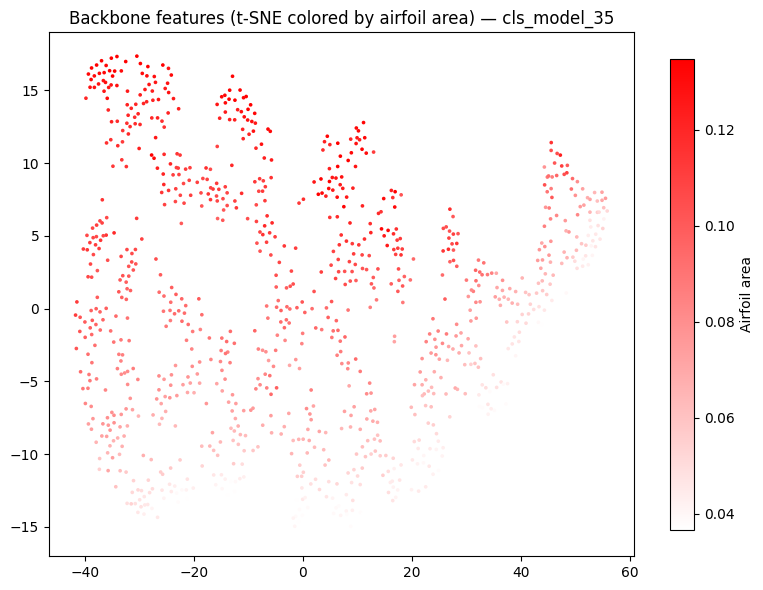

[cls_model_35] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_centered\cls_model_35_tsne_camber.png


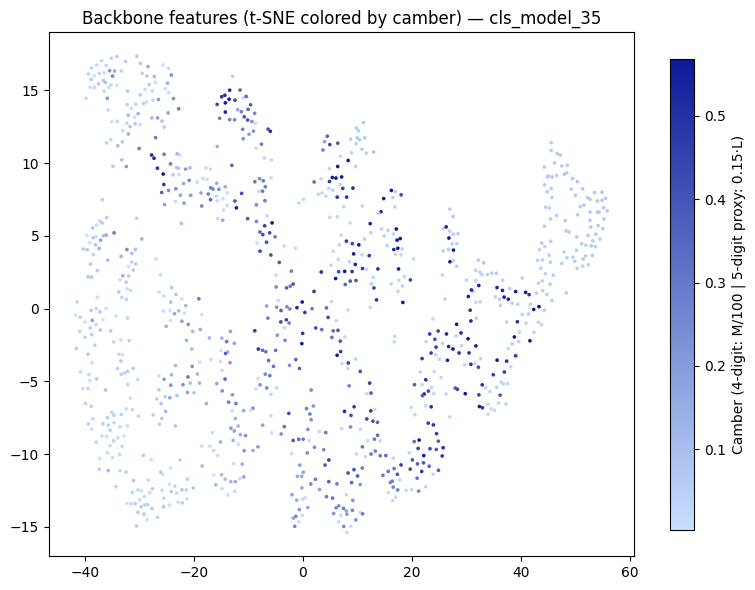

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_centered\cls_model_35_tsne_thickness.png


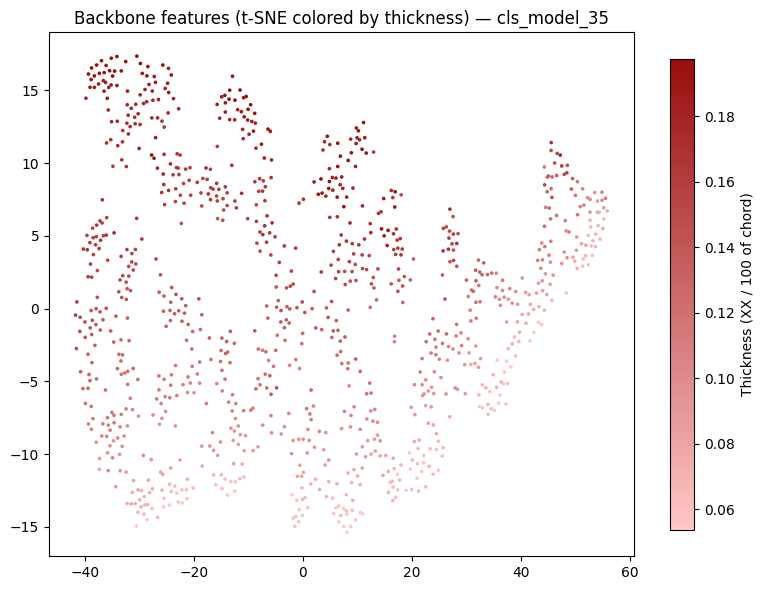

In [ ]:
out35 = analyze_pointnet_backbone2('models/point_net/trained_models/cls_focal_clr/cls_model_35.pth', DEVICE, class_choice = ["centered"],plots = plots, data_folder = "shapenet_like_out3")

1000
[cls_model_35] Model loaded from: models/point_net/trained_models/cls_focal_clr/cls_model_35.pth
[cls_model_35] Collected features: X=(1000, 1024), labels=(1000,)
[cls_model_35] Saved extracted features to:
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_normalized\cls_model_35_normalized_features.csv
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_normalized\cls_model_35_normalized_features.parquet
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.020s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.000132
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.128086
[t-SNE] KL divergence after 1000 iterations: 0.468895
[cls_model_35] t-SNE computed:

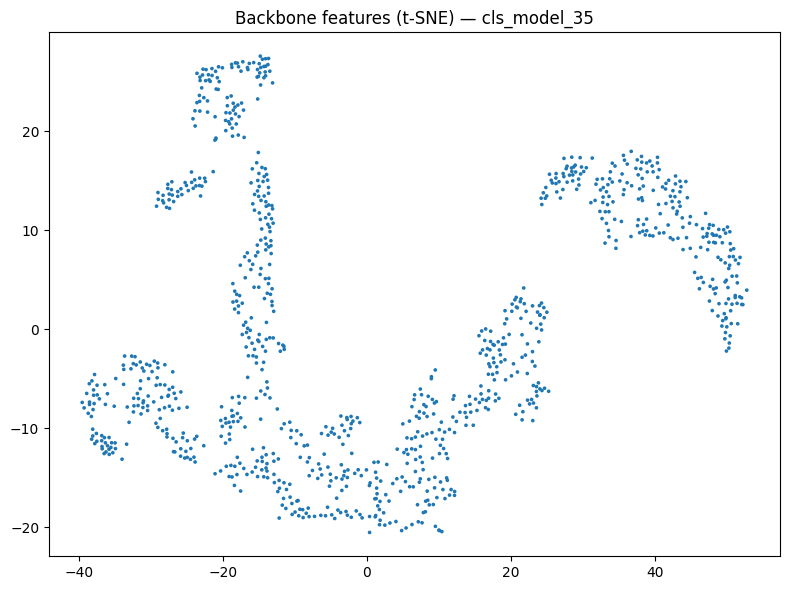

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_normalized\cls_model_35_tsne_area.png


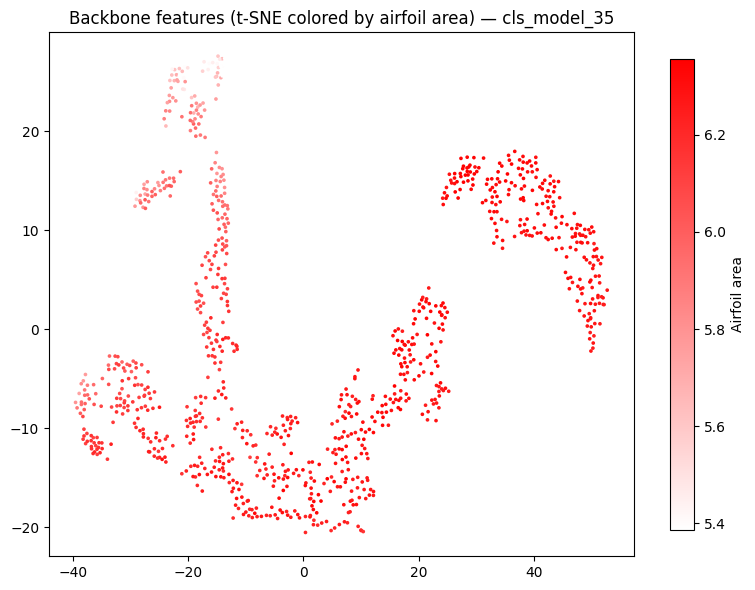

[cls_model_35] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_normalized\cls_model_35_tsne_camber.png


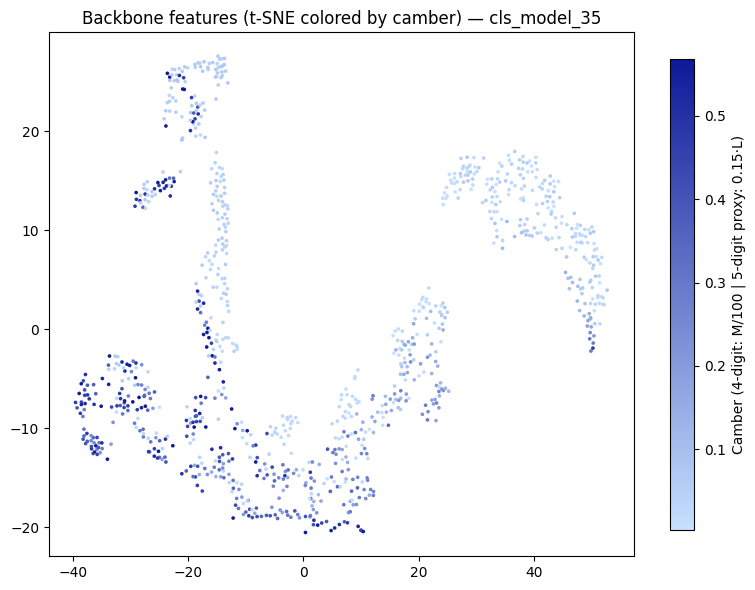

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_normalized\cls_model_35_tsne_thickness.png


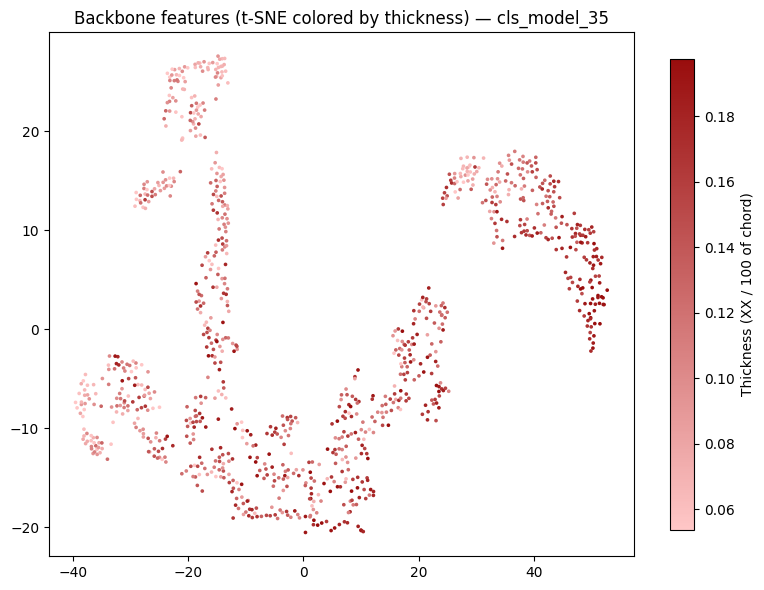

In [ ]:
out35 = analyze_pointnet_backbone2('models/point_net/trained_models/cls_focal_clr/cls_model_35.pth', DEVICE, class_choice = ["normalized"],plots = plots, data_folder = "shapenet_like_out3")

1000
[cls_model_35] Model loaded from: models/point_net/trained_models/cls_focal_clr/cls_model_35.pth
[cls_model_35] Collected features: X=(1000, 1024), labels=(1000,)
[cls_model_35] Saved extracted features to:
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_Extruded_default_thin_uniform\cls_model_35_Extruded_default_thin_uniform_features.csv
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_Extruded_default_thin_uniform\cls_model_35_Extruded_default_thin_uniform_features.parquet
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.011s...
[t-SNE] Computed neighbors for 1000 samples in 0.011s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.000378
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.079632
[t-SNE] 

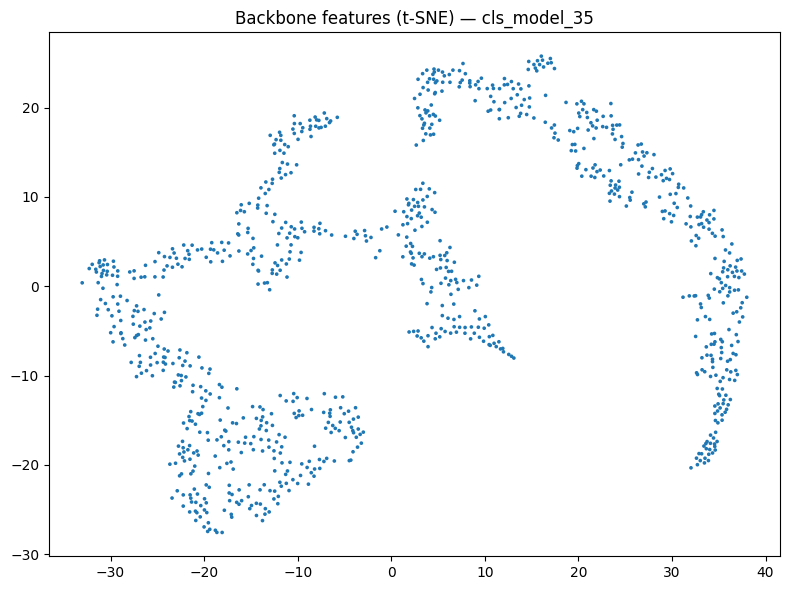

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_Extruded_default_thin_uniform\cls_model_35_tsne_area.png


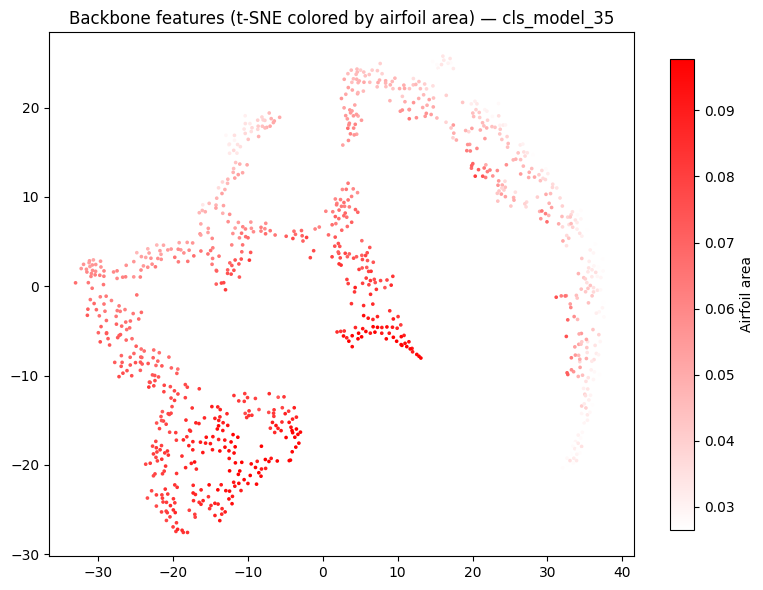

[cls_model_35] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_Extruded_default_thin_uniform\cls_model_35_tsne_camber.png


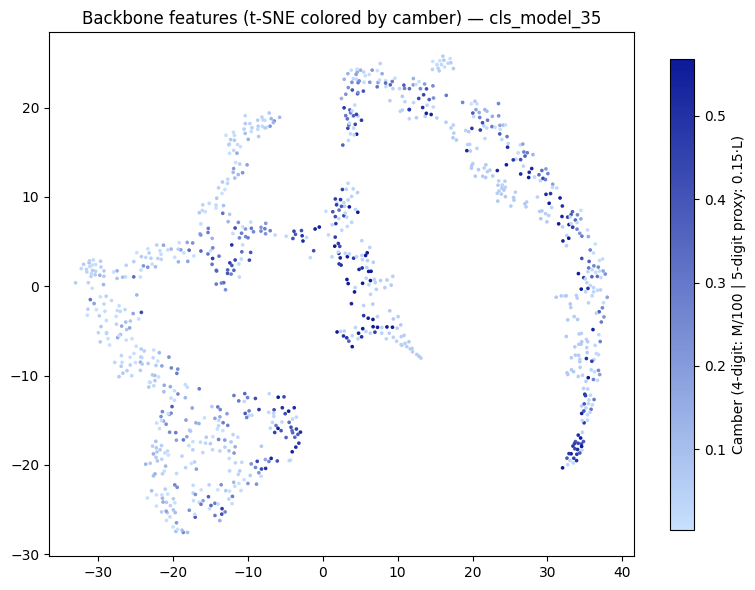

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_Extruded_default_thin_uniform\cls_model_35_tsne_thickness.png


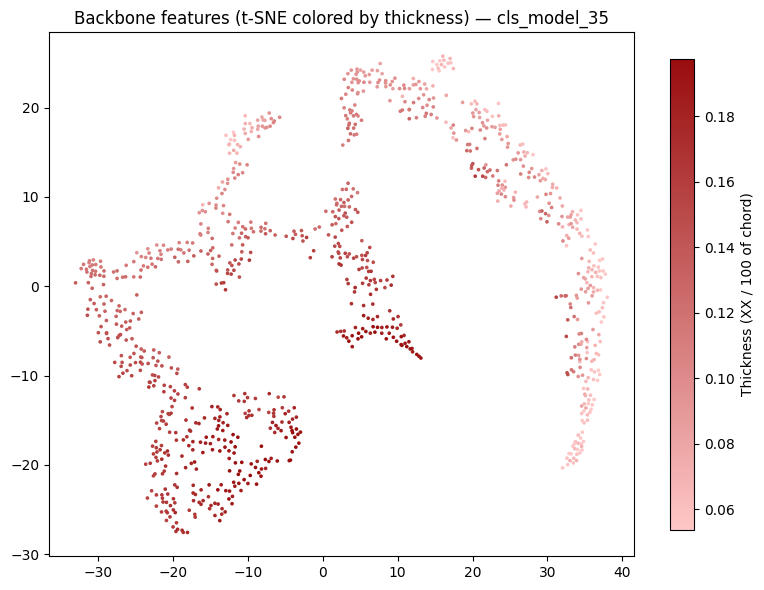

In [ ]:
out35 = analyze_pointnet_backbone2('models/point_net/trained_models/cls_focal_clr/cls_model_35.pth', DEVICE, class_choice = ["Extruded_default_thin_uniform"], plots = plots, data_folder = "shapenet_like_out3")

1000
[cls_model_35] Model loaded from: models/point_net/trained_models/cls_focal_clr/cls_model_35.pth
[cls_model_35] Collected features: X=(1000, 1024), labels=(1000,)
[cls_model_35] Saved extracted features to:
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_torus_default\cls_model_35_torus_default_features.csv
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_torus_default\cls_model_35_torus_default_features.parquet
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.021s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.000025
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.942776
[t-SNE] KL divergence after 1000 iterations: 0.885145
[cls_model_35] t-S

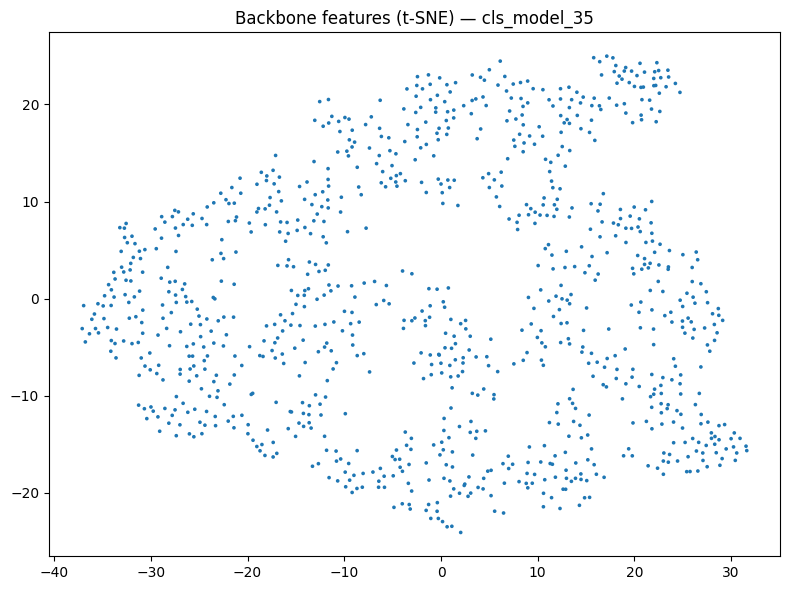

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_torus_default\cls_model_35_tsne_area.png


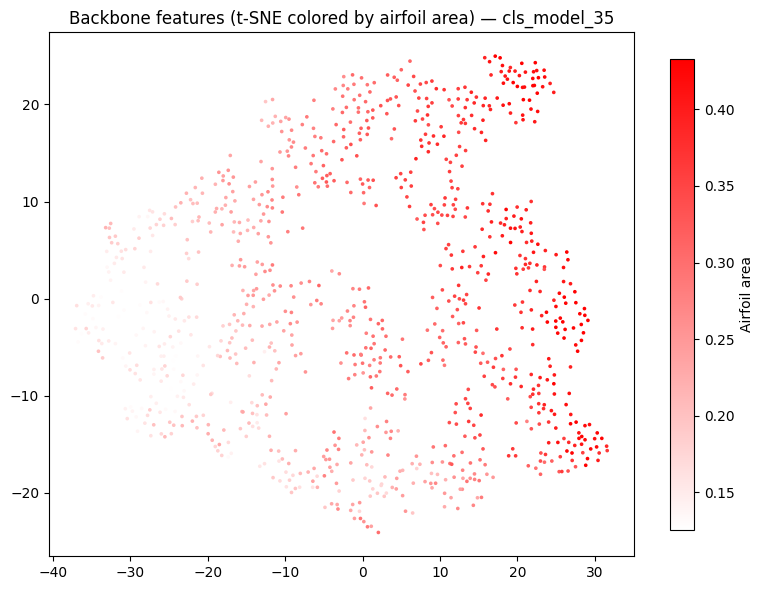

[cls_model_35] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_torus_default\cls_model_35_tsne_camber.png


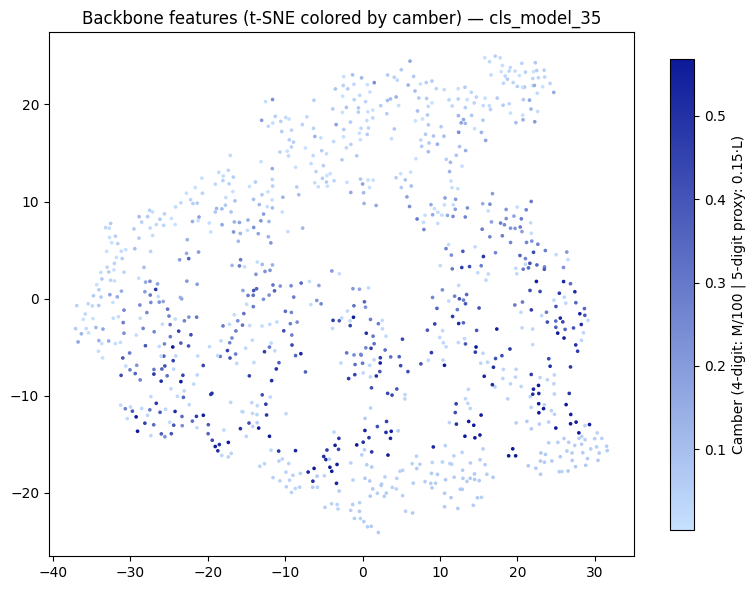

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_torus_default\cls_model_35_tsne_thickness.png


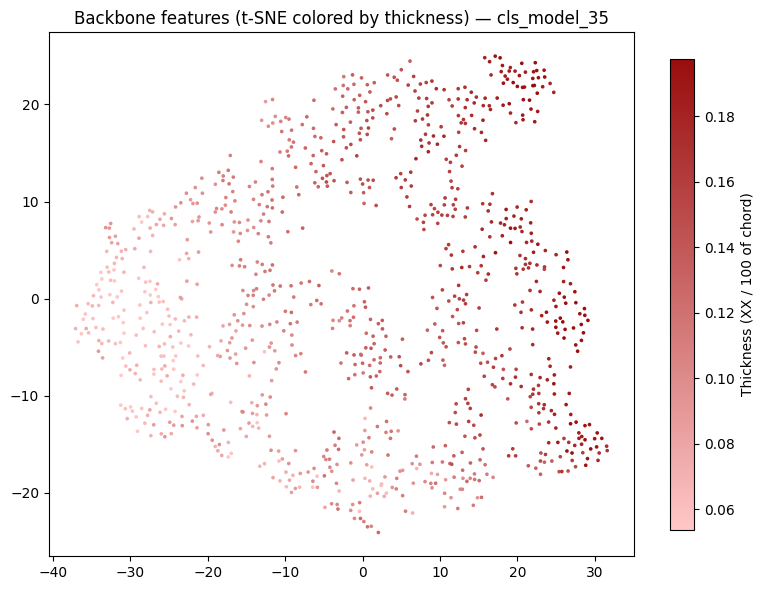

In [ ]:
out35 = analyze_pointnet_backbone2('models/point_net/trained_models/cls_focal_clr/cls_model_35.pth', DEVICE, class_choice = ["torus_default"], plots = plots, data_folder = "shapenet_like_out3")

1000
[cls_model_35] Model loaded from: models/point_net/trained_models/cls_focal_clr/cls_model_35.pth
[cls_model_35] Collected features: X=(1000, 1024), labels=(1000,)
[cls_model_35] Saved extracted features to:
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_OT_2D\cls_model_35_OT_2D_features.csv
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_OT_2D\cls_model_35_OT_2D_features.parquet
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.026s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.001325
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.486973
[t-SNE] KL divergence after 1000 iterations: 0.778542
[cls_model_35] t-SNE computed: X2=(1000, 2)
[plot]

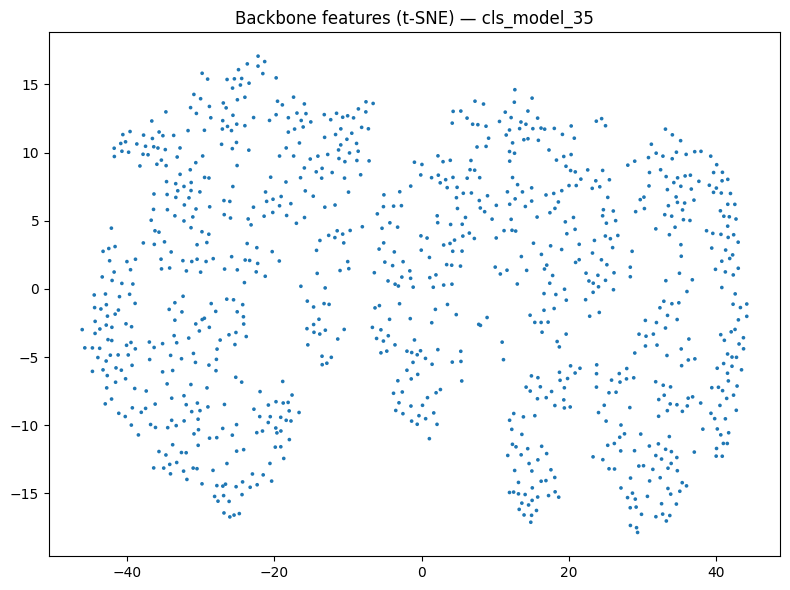

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_OT_2D\cls_model_35_tsne_area.png


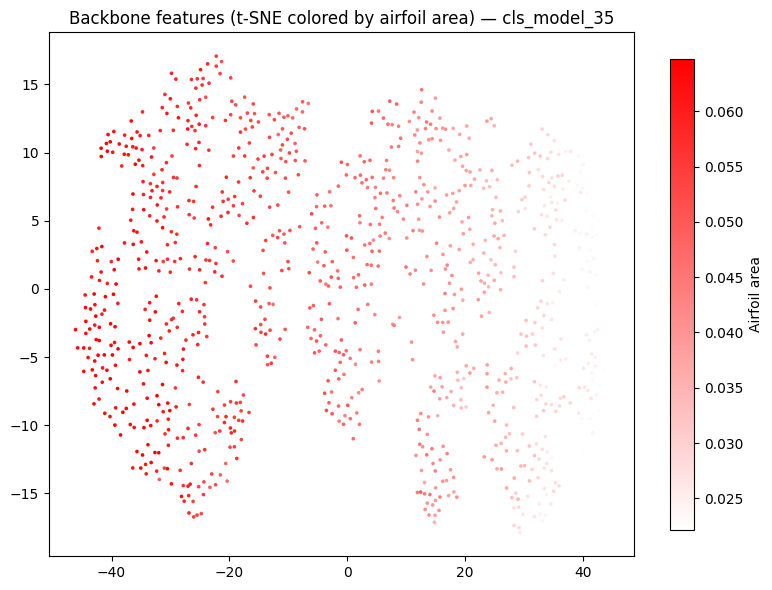

[cls_model_35] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_OT_2D\cls_model_35_tsne_camber.png


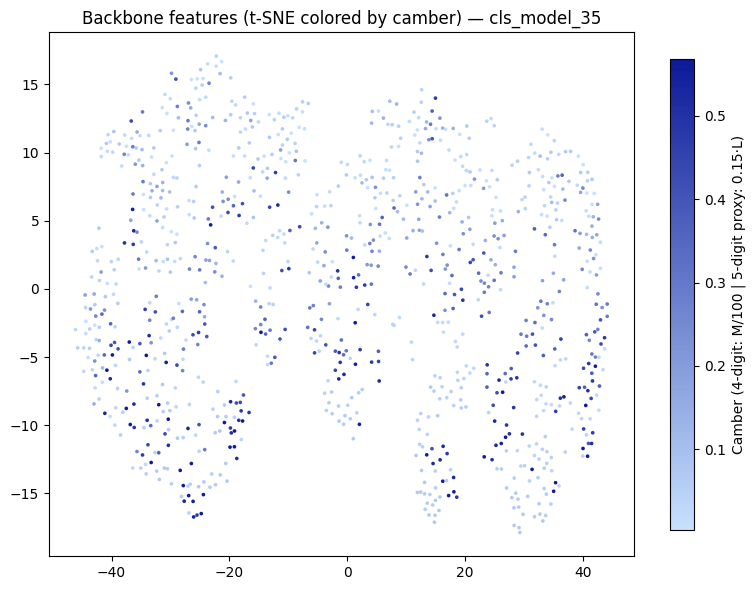

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_OT_2D\cls_model_35_tsne_thickness.png


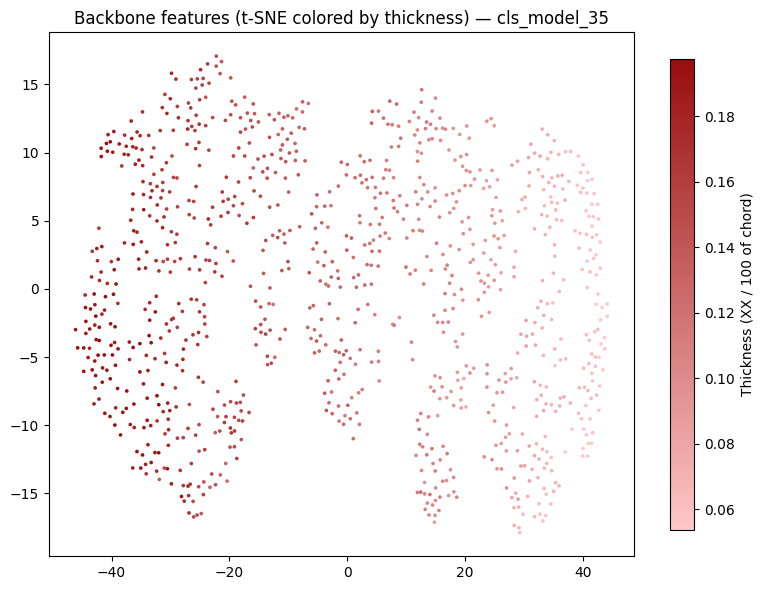

In [ ]:
out35 = analyze_pointnet_backbone2('models/point_net/trained_models/cls_focal_clr/cls_model_35.pth', DEVICE, class_choice = ["OT_2D"], plots = plots, data_folder = "shapenet_like_out3")

1000
[cls_model_35] Model loaded from: models/point_net/trained_models/cls_focal_clr/cls_model_35.pth
[cls_model_35] Collected features: X=(1000, 1024), labels=(1000,)
[cls_model_35] Saved extracted features to:
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_OT_3D\cls_model_35_OT_3D_features.csv
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_OT_3D\cls_model_35_OT_3D_features.parquet
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.000s...
[t-SNE] Computed neighbors for 1000 samples in 0.020s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.001651
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.315884
[t-SNE] KL divergence after 1000 iterations: 0.825707
[cls_model_35] t-SNE computed: X2=(1000, 2)
[plot]

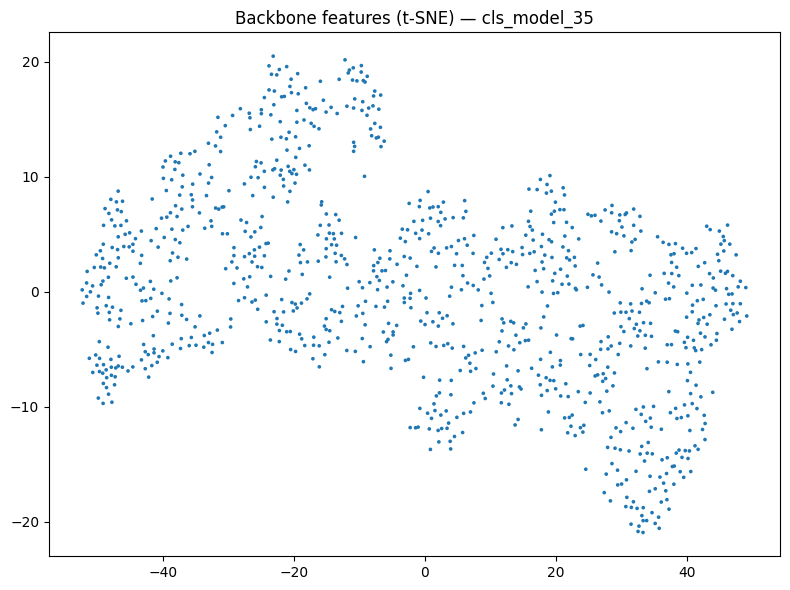

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_OT_3D\cls_model_35_tsne_area.png


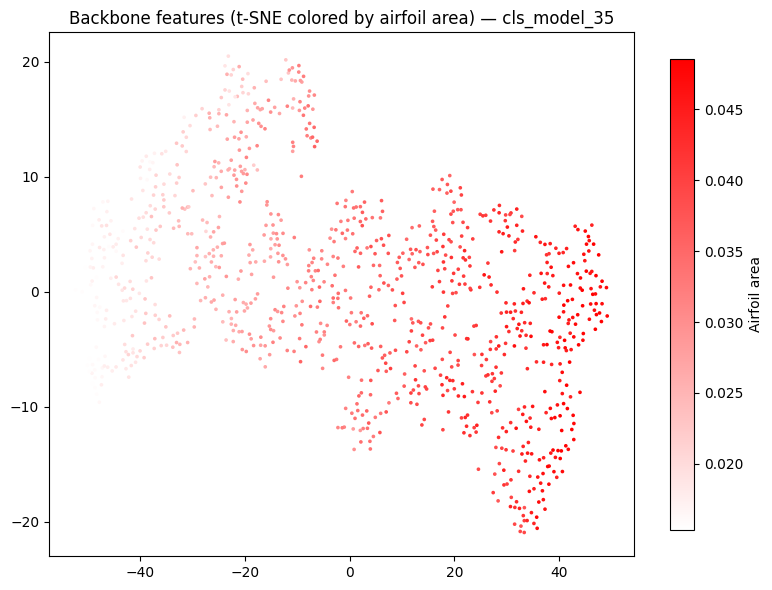

[cls_model_35] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_OT_3D\cls_model_35_tsne_camber.png


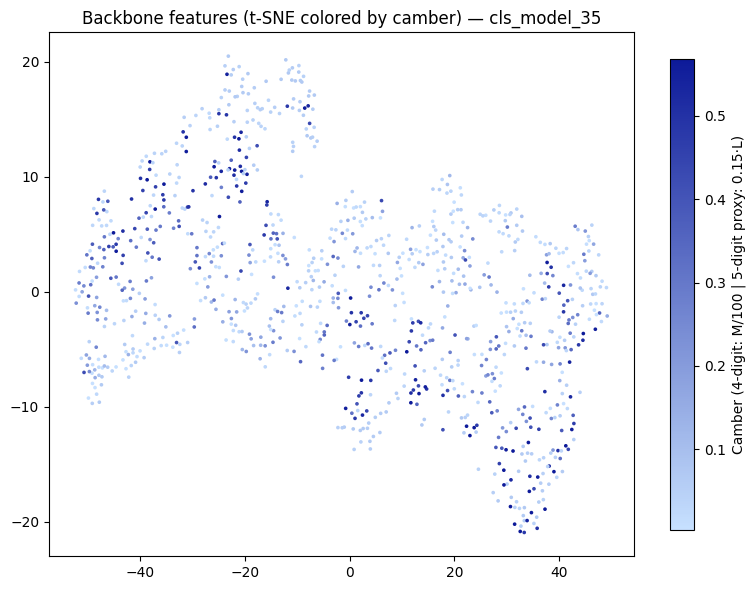

[plot] saved c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_OT_3D\cls_model_35_tsne_thickness.png


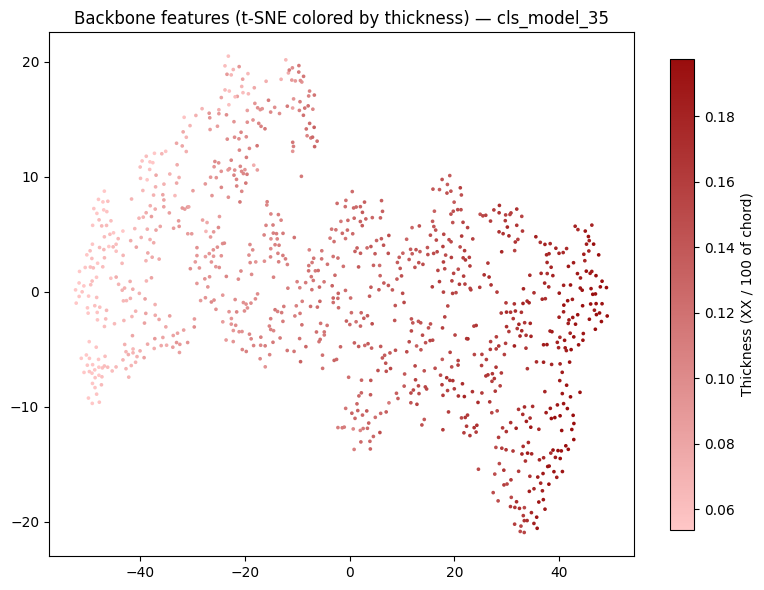

In [ ]:
out35 = analyze_pointnet_backbone2('models/point_net/trained_models/cls_focal_clr/cls_model_35.pth', DEVICE, class_choice = ["OT_3D"], plots = plots, data_folder = "shapenet_like_out3")

# Baseline: extract feature from the real dataset 

In [ ]:
class_choice = [
    "Airplane",
    "Bag",
    "Cap",
    "Car",
    "Chair",
    "Earphone",
    "Guitar",
    "Knife",
    "Lamp",
    "Laptop",
    "Motorbike",
    "Mug",
    "Pistol",
    "Rocket",
    "Skateboard",
    "Table"
]

result = analyze_pointnet_backbone2('models/point_net/trained_models/cls_focal_clr/cls_model_35.pth', DEVICE, class_choice = class_choice, data_folder = "shapenetcore_partanno_segmentation_benchmark_v0", plots=False, shapenenet = True)

2874
[cls_model_35] Model loaded from: models/point_net/trained_models/cls_focal_clr/cls_model_35.pth
[cls_model_35] Collected features: X=(2874, 1024), labels=(2874,)
[cls_model_35] Saved extracted features to:
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_Airplane\cls_model_35_Airplane_features.csv
  - c:\Users\romai\Desktop\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE copy\extracted_features\cls_model_35_Airplane\cls_model_35_Airplane_features.parquet


[t-SNE] Computing 2D projection on extracted features...


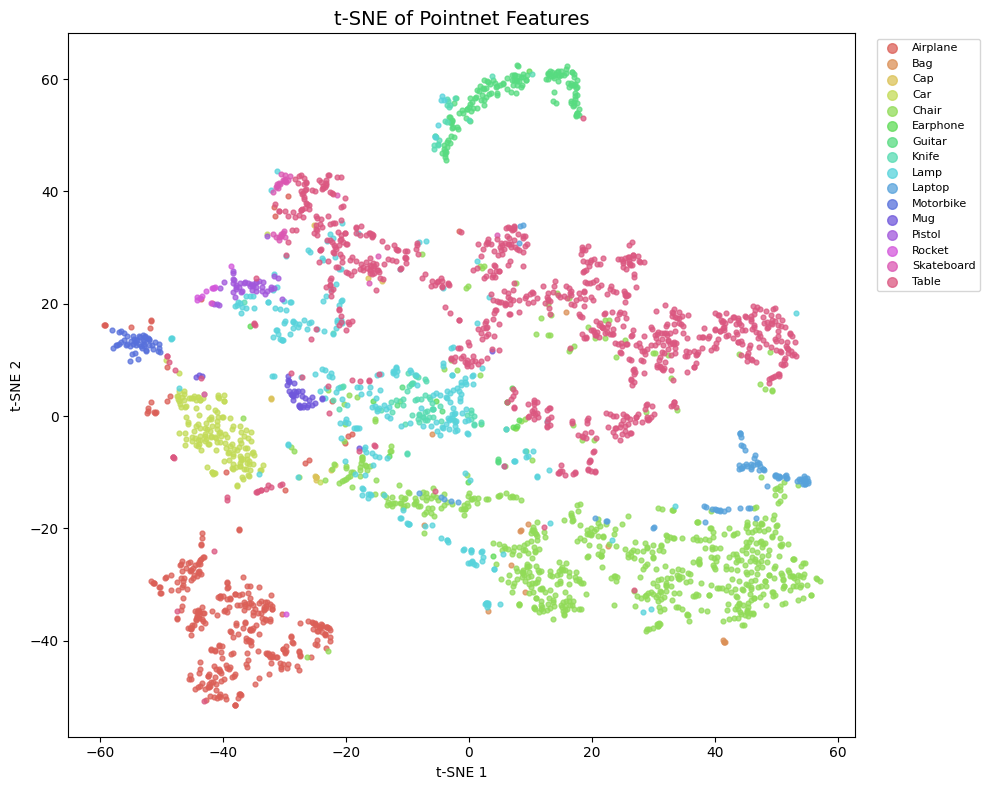

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

X = result["features"]   # numpy array (N, C)
y = result["labels"].squeeze()     # numpy array (N,)
print("[t-SNE] Computing 2D projection on extracted features...")
X_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init="pca"
).fit_transform(X)

# Colors per category
unique_labels = np.unique(y)
palette = sns.color_palette("hls", len(unique_labels))

plt.figure(figsize=(10, 8))
for i, lab in enumerate(unique_labels):
    idx = y == lab
    plt.scatter(
        X_2d[idx, 0],
        X_2d[idx, 1],
        s=12,
        alpha=0.75,
        color=palette[i],
        label=class_choice[lab]
    )

plt.title("t-SNE of Pointnet Features", fontsize=14)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(
    markerscale=2,
    fontsize=8,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()
